In [4]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_n import run_coincidence_vs_n
from src.coincidence_theory import get_C

<h1> Run the experiment </h1>

In [7]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Order of the bare parameters
n_tab = [-1,0,1,2,3,4,5]

#Different photon frequencies
omega_q_tab = [9.5*pi, 9*pi, 8.5*pi]
delta_q = 0.05*pi


#Prepare frequency windows
frequency_windows = [(0*pi, 20*pi),
                    (0*pi, 19*pi),
                    (0*pi, 18*pi),
                    (0*pi, 17*pi)]

Run the experiment

In [ ]:
index_omega_q_to_run = [3]
xp_to_run = [2,3,4]

for index_omega_q in index_omega_q_to_run:
        for index_experiment in xp_to_run:
                print(f"Running index omega q {index_omega_q} for frequency window {index_experiment}")

                omega_q = omega_q_tab[index_omega_q-1]

                cutoffs = {'ir_cutoff': frequency_windows[index_experiment-1][0], 'uv_cutoff': frequency_windows[index_experiment-1][1]}
                
                #Parameters of the simulation
                L = 50

                param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

                param_time_evol = {'T': L/2, 'dt': 0.01}

                param_photons = {'omega_p': [omega_q, omega_q], 
                                'delta_k': [delta_q, delta_q],
                                'x_0': [-L/4, -L/4]}
                        
                _, coincidence_tab = run_coincidence_vs_n(param_photons, param_cavity_physical, param_time_evol, cutoffs, n_tab,
                                                          index_omega_q=index_omega_q, index_experiment=index_experiment)
                
                print("------------- \n")

Running index omega q 3 for frequency window 2


100%|██████████| 7/7 [10:24<00:00, 89.24s/it]


------------- 

Running index omega q 3 for frequency window 3


100%|██████████| 7/7 [09:12<00:00, 78.90s/it]


------------- 

Running index omega q 3 for frequency window 4


100%|██████████| 7/7 [07:53<00:00, 67.68s/it]

------------- 



<h1> Results </h1>

Load the data and create the figure

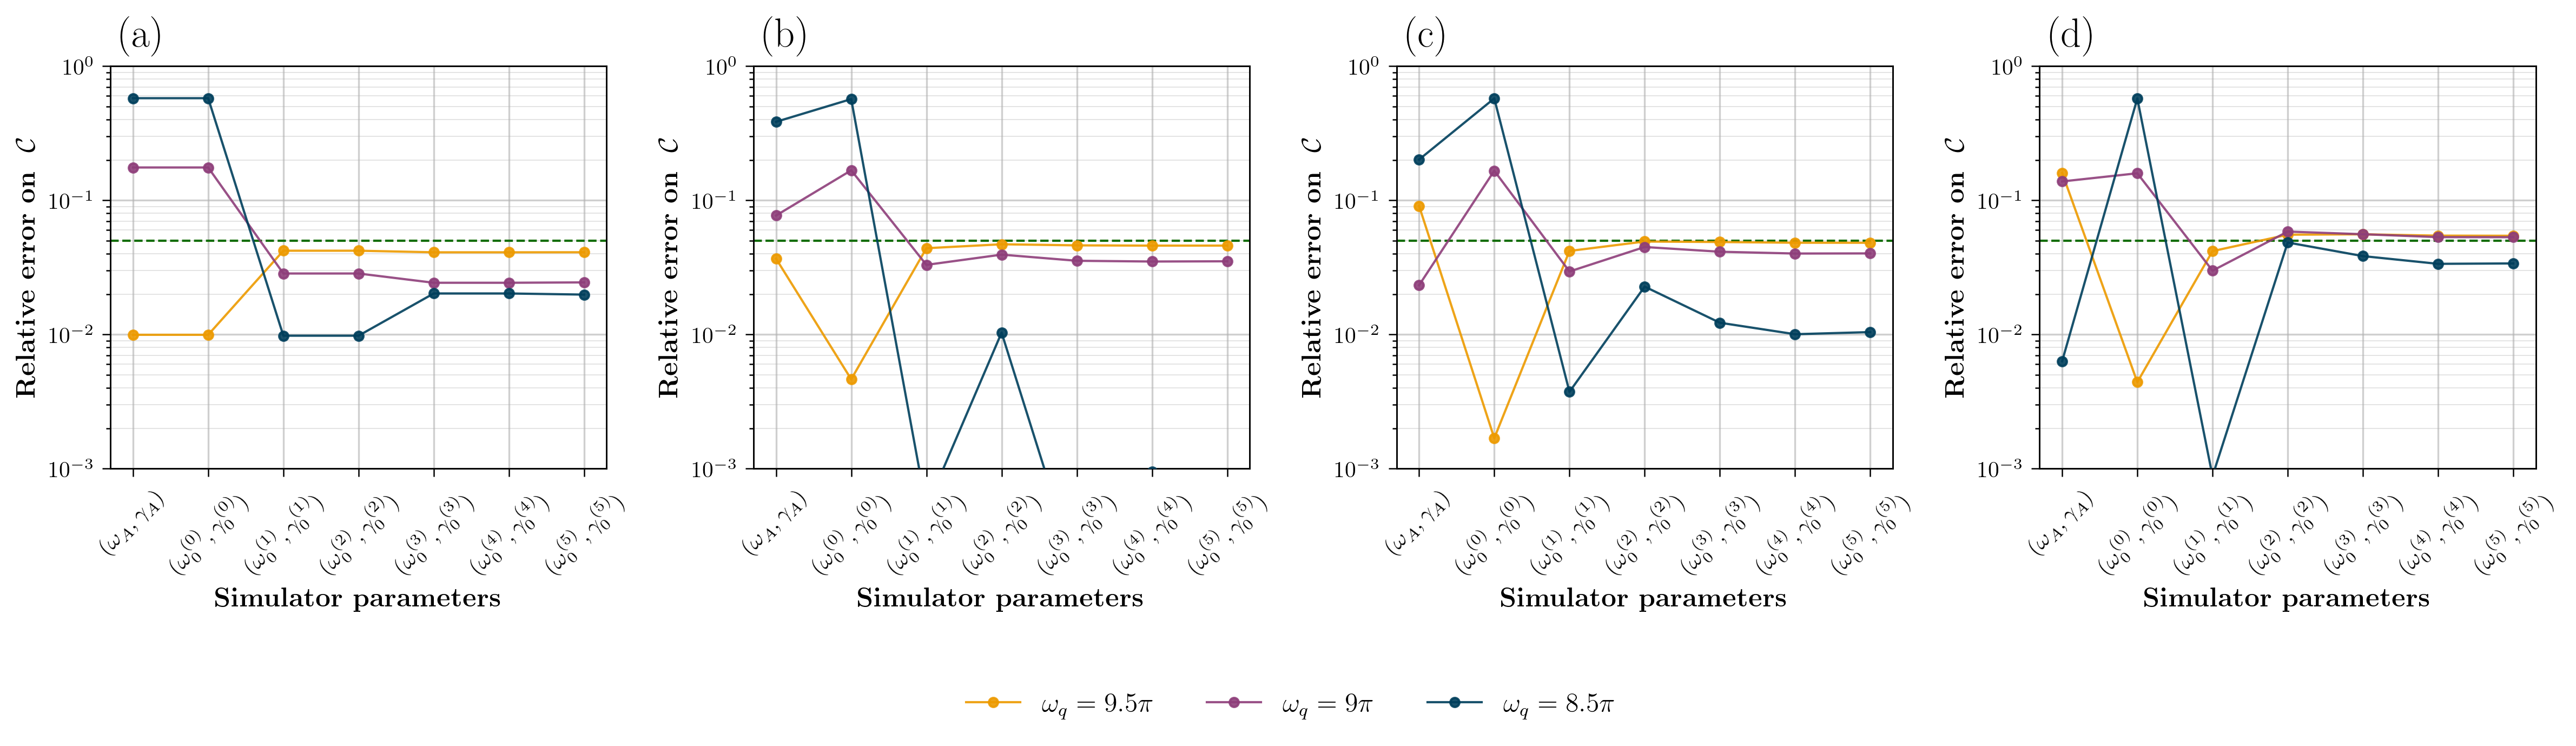

In [12]:
# =========================
# Paramètres
# =======================
xp_tab = [1,2,3,4]

colors = ["#ed9a00","#8e3e7a","#003f5c"]
labels = [r'$\omega_q = 9.5\pi$', r'$\omega_q = 9\pi$', r'$\omega_q = 8.5\pi$']

subfig_labels = [r'(a)', r'(b)', r'(c)', r'(d)']

# =========================
# Figure
# =========================
fig, axs = plt.subplots(1,4, figsize=(16,4), dpi=300, sharey=False)
axs = axs.flat

fig.subplots_adjust(wspace=0.3)

# =========================
# Boucle sur expériences
# =========================
for idx, ax in enumerate(axs):

    index_experiment = xp_tab[idx]

    # -------------------------
    # boucle sur fréquences
    # -------------------------
    for j in range(len(omega_q_tab)):

        index_omega_q = j+1
        omega_q = omega_q_tab[index_omega_q-1]

        # théorie
        theoretical_val = get_C(omega_A, Gamma, omega_q)

        # Recover the data
        data_file = f"../results/csv_files/coincidence_vs_n/coincidence_vs_n_omega{index_omega_q}_xp{index_experiment}.csv"
        df = pd.read_csv(data_file)
        coincidence_tab = df['coincidence_tab'].to_numpy()

        relative_error = np.abs(coincidence_tab - theoretical_val)/theoretical_val


        # -------------------------
        # plot fréquence
        # -------------------------
        ax.plot(
            n_tab,
            relative_error,
            marker='o',
            markersize=4,
            linewidth=1,
            color=colors[j],
            label=labels[j],
            alpha=0.9,
            zorder=3
        )


    # =========================
    # threshold 5%
    # =========================
    ax.axhline(
        0.05,
        color='#136d05',
        linestyle='--',
        linewidth=1
    )

    # =========================
    # axes
    # =========================
    ax.set_xticks(n_tab)

    ax.set_xticklabels([
        r'$(\omega_A,\gamma_A)$',
        r'$(\omega_0^{(0)},\gamma_0^{(0)})$',
        r'$(\omega_0^{(1)},\gamma_0^{(1)})$',
        r'$(\omega_0^{(2)},\gamma_0^{(2)})$',
        r'$(\omega_0^{(3)},\gamma_0^{(3)})$',
        r'$(\omega_0^{(4)},\gamma_0^{(4)})$',
        r'$(\omega_0^{(5)},\gamma_0^{(5)})$'
    ])

    ax.tick_params(axis='x', labelrotation=45)

    ax.set_yscale('log')
    ax.set_ylim([1e-3,1e0])

    ax.grid(which='major', linewidth=0.8, alpha=0.6)
    ax.grid(which='minor', linewidth=0.4, alpha=0.4)

    # subplot label
    ax.text(
        0.02,1.05,
        subfig_labels[idx],
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold'
    )

    ax.set_ylabel(r'\textbf{Relative error on } $\mathcal{C}$',fontsize=12)
    ax.set_xlabel(r'\textbf{Simulator parameters}', fontsize=12)

# =========================
# légende globale
# =========================
handles, _ = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5,-0.05),
    ncol=3,
    frameon=False,
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "../results/fig/coincidence_vs_N.pdf",
    bbox_inches="tight"
)

plt.show()